# Notebook 1: Dane i przetwarzanie wstępne

**Autor:** Michał Bogdański

**Opis:** Projekt realizuje sentymentu recenzji steam po angielsku. Porównujemy podejście klasyczne (TF-IDF + SVM) z podejściem opartym na Transformerach (HerBERT).

**Źródło danych:** Zbiór `Steam Reviews` z kaggle.com – podział na oceny pozytywne i negatywne.

W tym notebooku:
1. Ładujemy dane
2. Przeprowadzamy eksploracyjną analizę danych (EDA)
3. Wykonujemy przetwarzanie wstępne tekstu
4. Dzielimy dane na zbiory treningowy, walidacyjny i testowy

## 1. Instalacja i import bibliotek

In [9]:
!pip install datasets pandas matplotlib seaborn scikit-learn wordcloud spacy -q
!python -m spacy download pl_core_news_sm -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import spacy
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Ustawienia wyświetlania
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

## 2. Załadowanie danych

Korzystamy ze zbioru `Steam Reviews` dostępnego na kaggle.com. Zbiór zawiera recenzje gier ze steam (pozytywne/negatywne)

In [8]:
df = pd.read_csv("final_fantasy_XIII.csv")
df = df.dropna()
print(f"Liczba rekordów: {len(df)}")
print(f"Kolumny: {list(df.columns)}")
df.head()

Liczba rekordów: 3899
Kolumny: ['review_text', 'review_score']


,review_text,review_score
0,"This game has a tremendous polarizing effect on gamers. Either you love it, or you hate it. Hence I'm not surprised to see such mixed reviews. (Of course, the poor port is adding fuel to the negat...",1
1,"From what I have gathered, this game is somewhat controversial. I have 3 playthroughs now, looking forward to a 4th, and I would like to bring up a few points and offer my opinions, that potential...",1
2,"It's really hard to talk about this game. I've finally beaten Final Fantasy XIII and the first thing that comes to mind is, it really is a unique experience. So, is it good? Well, I can't say I li...",-1
3,"ok, now i finally beat this game, time for a review english is not my main language, so bear with it.",1
4,This review is spoiler-free. First things first: let me list some important points which may very well influence you taking my recommendation seriously. I am new to Final Fantasy series. I h...,1


In [9]:
print("Podgląd kolumn i typów:")
print(df.dtypes)

Podgląd kolumn i typów:
review_text       str
review_score    int64
dtype: object


In [10]:
# review_score, 1 - pozytywne, -1 - negatywne
TEXT_COL = "review_text"
RATING_COL = "review_score"

print(f"\nRozkład sentymentu:")
print(df[RATING_COL].value_counts())


Rozkład sentymentu:
review_score
 1    2805
-1    1094
Name: count, dtype: int64


## 3. Eksploracyjna analiza danych (EDA)

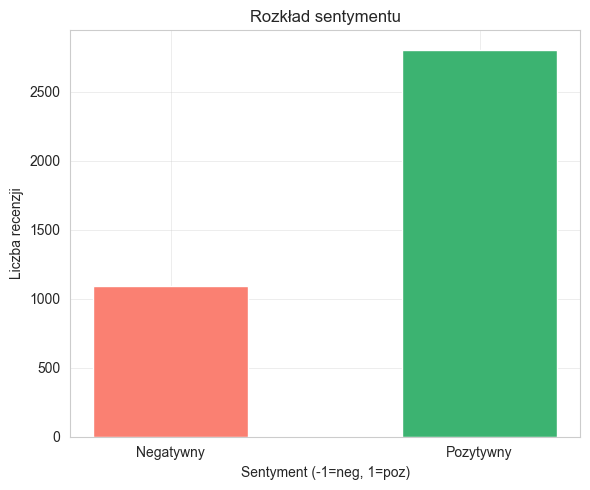

In [11]:
# Rozkład recenzji
counts = df[RATING_COL].value_counts().sort_index()
labels = ["Negatywny", "Pozytywny"]
colors = ["salmon", "mediumseagreen"]

plt.figure(figsize=(6, 5))
plt.bar(labels, counts, color=colors, width=0.5)

plt.title("Rozkład sentymentu")
plt.xlabel("Sentyment (-1=neg, 1=poz)")
plt.ylabel("Liczba recenzji")

plt.tight_layout()
plt.show()

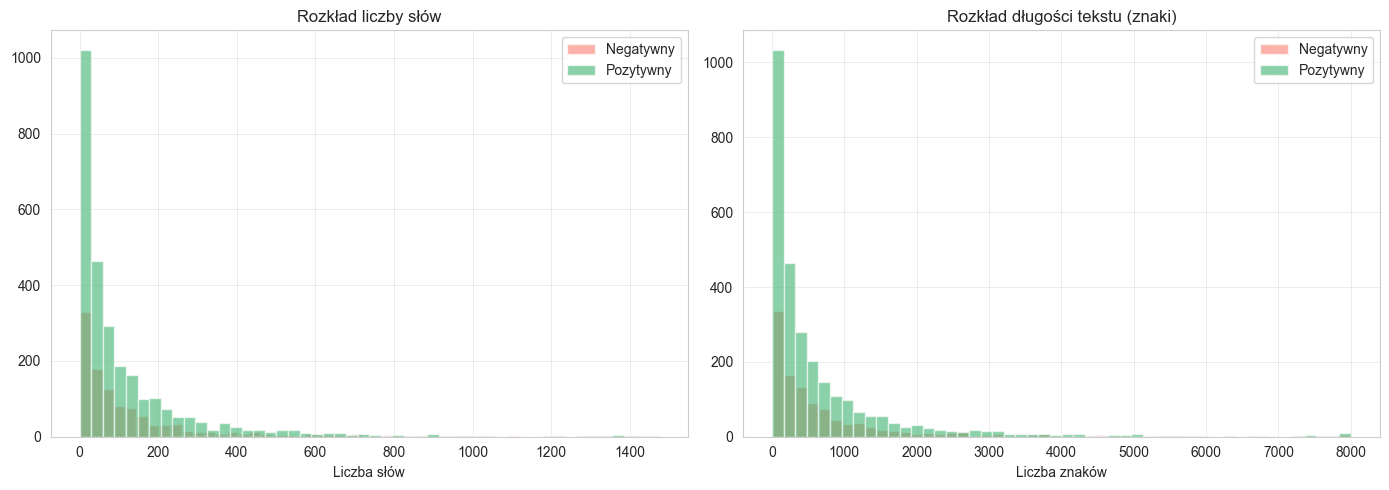

Statystyki długości recenzji (słowa):
               count        mean         std  min   25%   50%    75%     max
review_score                                                                
-1            1094.0  138.809872  200.824003  1.0  25.0  67.5  162.0  1435.0
 1            2805.0  121.104100  185.987776  0.0  17.0  53.0  144.0  1473.0


In [13]:
# Długość recenzji
df["text_length"] = df[TEXT_COL].astype(str).apply(len)
df["word_count"] = df[TEXT_COL].astype(str).apply(
    lambda x: len(x.split())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sent, color, label in [(-1, "salmon", "Negatywny"), (1, "mediumseagreen", "Pozytywny")]:
    subset = df[df[RATING_COL] == sent]
    axes[0].hist(subset["word_count"], bins=50, alpha=0.6, label=label, color=color)
    axes[1].hist(subset["text_length"], bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title("Rozkład liczby słów")
axes[0].set_xlabel("Liczba słów")
axes[0].legend()

axes[1].set_title("Rozkład długości tekstu (znaki)")
axes[1].set_xlabel("Liczba znaków")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statystyki długości recenzji (słowa):")
print(df.groupby(RATING_COL)["word_count"].describe())

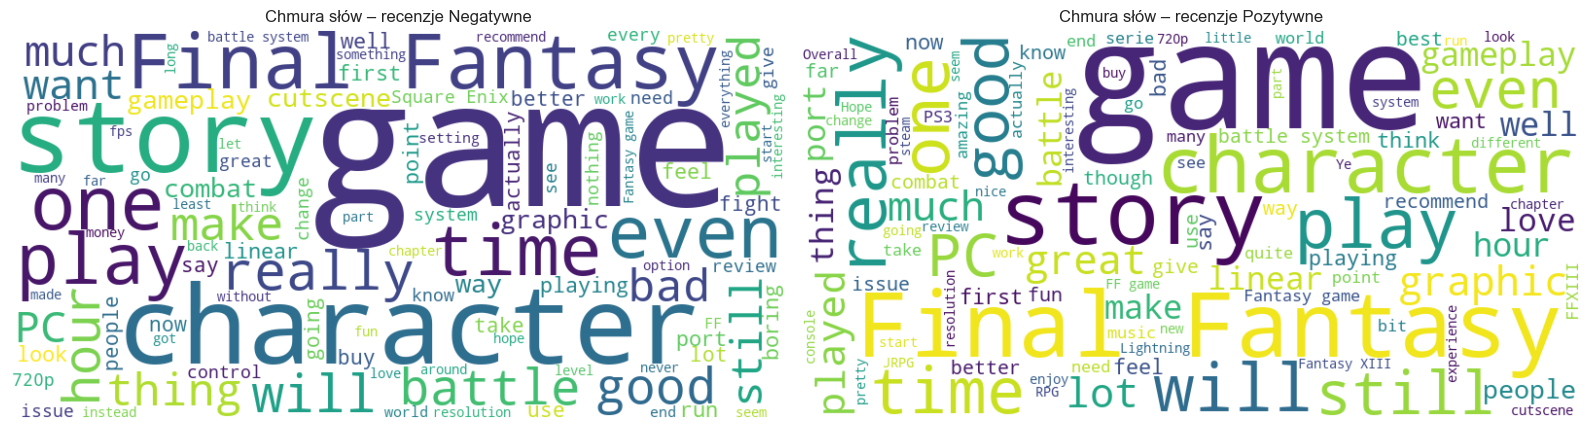

In [16]:
# Najczęstsze słowa dla każdego sentymentu
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (sent, title) in enumerate([(-1, "Negatywne"), (1, "Pozytywne")]):
    texts = " ".join(df[df[RATING_COL] == sent][TEXT_COL].astype(str))
    wc = WordCloud(
        width=800, height=400, background_color="white", max_words=100
    ).generate(texts)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Chmura słów – recenzje {title}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()